In [1]:
import numpy as np
import numpy.random as rand
import matplotlib.pyplot as plt

In [2]:
def onBoard(i, j, image):
    ni = image.shape[0] # number of pixels (height)
    nj = image.shape[1] # number of pixels (width)
    if i <= ni-1 and i >= 0 and j <= ni-1 and j >= 0: # You need some more conditions here! 
                                         # We've checked i, but what about j?
        return True
    else:
        return False

In [3]:
def getNeighborValues(i,j, board):
    # The following list contains the indices of the neighbors for a pixel at (i.j)
    neighborhood = [(i-1, j), (i, j-1), (i+1, j), (i, j+1), (i-1,j-1), (i+1,j-1), (i-1,j+1), (i+1,j+1)]
    
    neighbor_values = []
    for neighbor in neighborhood:  
        if onBoard(neighbor[0],neighbor[1],board)==True:
            x = board[neighbor]
            neighbor_values.append(x)

        pass
    
    return neighbor_values

In [24]:
def plotgrid(myarray):
    
    # 
    x_range = np.linspace(0, myarray.shape[1]-1, myarray.shape[1]) 
    y_range = np.linspace(0, myarray.shape[0]-1, myarray.shape[0]) # repeat for the y/vertical axis
    
    # 
    x_indices, y_indices = np.meshgrid(x_range, y_range)
    
    # 
    tree_x = x_indices[myarray == 1];   
    tree_y = y_indices[myarray == 1]; 
    
    # 
    ax = plt.axes()
    ax.set_facecolor('purple')
    plt.plot(tree_x, myarray.shape[0] - tree_y - 1, 'ys',markersize=10)
    
    # 
    plt.xlim([-1,myarray.shape[1]])
    plt.ylim([-1,myarray.shape[0]]) 

    # 
    plt.tick_params(axis='both', which='both',
                    bottom=False, top=False, left=False, right=False,
                    labelbottom=False, labelleft=False)

In [25]:
def set_board(board_size=50,f_trees_start=0.5):
    '''
    Creates the initial game board.

    Inputs:
        board_size: length of one edge of the board
        f_trees_start: probability that a given cell is a tree
                       (effectively the tree density)

    Outputs a 2D numpy array with values set to either 0, 1, or 2
        (empty, tree, or fire)
    '''
    
    # all cells initialized to 'empty' (0) by default
    game_board = np.zeros((board_size,board_size),dtype='int64')
    
    # loop over board and roll the dice; if the random number is less
    # than f_trees_start, make it a tree.
    for i in range(board_size):
        for j in range(board_size):
            if rand.random() <= f_trees_start:
                game_board[i,j] = 1

    # set the whole left edge of the board on fire. We're arsonists!
    
    return game_board

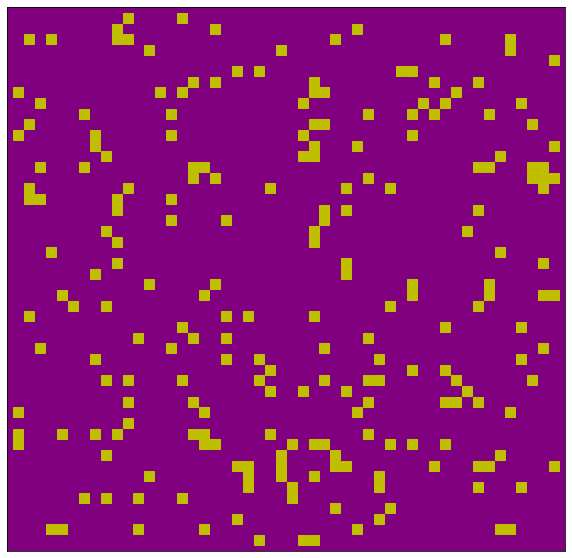

In [26]:
small_board = set_board(50, 0.1)
plt.figure(figsize=(10,10))
plotgrid(small_board)

In [27]:
def advance_board(game_board):
    '''
    Advances the game board using the given rules.
    Input: the initial game board.
    Output: the advanced game board
    '''
    
    # create a new array that's just like the original one, but initially set to all zeros (i.e., totally empty)
    new_board = np.zeros_like(game_board)
    
    # loop over each cell in the board and decide what to do.
    # You'll need two loops here, one nested inside the other.
    for i in range(game_board.shape[0]):
        for j in range(game_board.shape[1]):
                
            # Now that we're inside the loops we need to apply our rules
            
            # if the cell was empty last turn, it's still empty.
            
            if game_board[i,j]==0:
                t = getNeighborValues(i,j, game_board)
                x = t.count(1)
                if x==3:
                    new_board[i,j]=1
           
            if game_board[i,j]==1:
                t = getNeighborValues(i,j, game_board)
                x = t.count(1)
                if x<2 or x>3:
                    new_board[i,j]=0
                if 2<=x<=3:
                    new_board[i,j]=1
                

    # return the new board
    return new_board

In [28]:
yeet_board = set_board(50, 0.1)

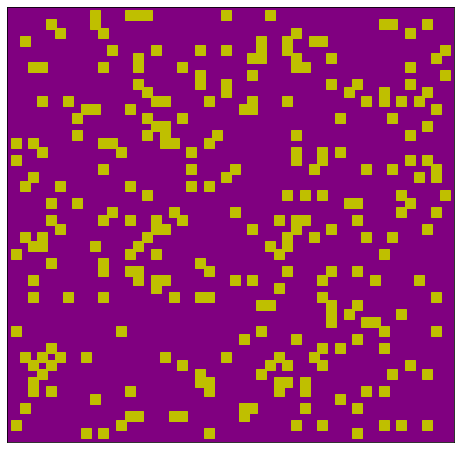

In [29]:
plt.figure(figsize=(8,8))
plotgrid(yeet_board)
yeet_board = advance_board(yeet_board)

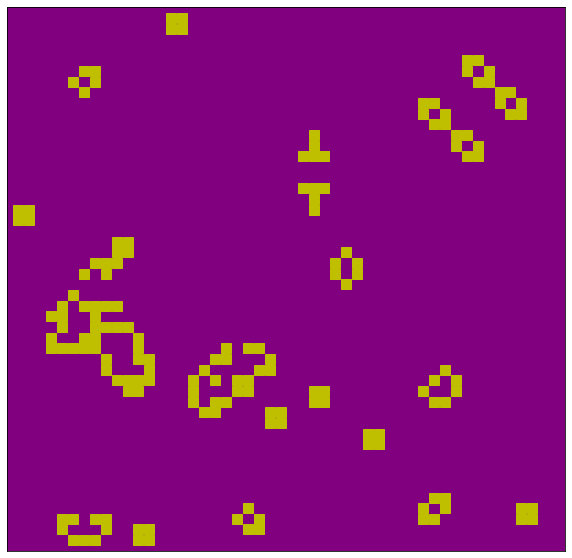

KeyboardInterrupt: 

<Figure size 720x720 with 0 Axes>

In [36]:
from IPython.display import display, clear_output

# We can use this to have images show up with some user-specified spacing in time
import time 

# Create a figure
fig = plt.figure(figsize=(10,10))

yeet_board = set_board(50, 0.2)

# Run animation for 10 iterations
while 1 in yeet_board:
    
    # Generate the random neighborhood, as in previous cells
    yeet_board = advance_board(yeet_board)   
    plotgrid(yeet_board)
    
    # Animation part 
    time.sleep(0.00001)         # Sleep for half a second to slow down the animation
    clear_output(wait=True) # Clear output for dynamic display
    display(fig)            # Reset display
    fig.clear()             # Prevent overlapping and layered plots

plt.close()     